In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import warnings
import gc
warnings.filterwarnings('ignore')

# Dataset paths
TRAIN_DIR = '/kaggle/input/brain-tumor-mri-dataset/Training'
TEST_DIR = '/kaggle/input/brain-tumor-mri-dataset/Testing'

print('Libraries imported successfully')

2026-02-04 01:38:17.067999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770169097.253971      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770169097.306949      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770169097.783535      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770169097.783583      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770169097.783586      24 computation_placer.cc:177] computation placer alr

Libraries imported successfully


In [2]:
def count_images_in_directory(base_dir):
    """
    Count number of images in each class folder
    """
    class_counts = {}
    
    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_counts[class_name] = len(image_files)
    
    return class_counts

# Count distribution in training set
print('DATASET DISTRIBUTION ANALYSIS')

train_counts = count_images_in_directory(TRAIN_DIR)
print('\nTraining Set Distribution:')
for class_name, count in sorted(train_counts.items()):
    print(f'  {class_name}: {count} images')
print(f'  Total: {sum(train_counts.values())} images')

# Count distribution in test set
test_counts = count_images_in_directory(TEST_DIR)
print('\nTest Set Distribution:')
for class_name, count in sorted(test_counts.items()):
    print(f'  {class_name}: {count} images')
print(f'  Total: {sum(test_counts.values())} images')


# Check if balanced
max_count = max(train_counts.values())
min_count = min(train_counts.values())
imbalance_ratio = max_count / min_count

print(f'\nClass Balance Check:')
print(f'  Max class size: {max_count}')
print(f'  Min class size: {min_count}')
print(f'  Imbalance ratio: {imbalance_ratio:.2f}')

if imbalance_ratio < 1.5:
    print('  Dataset is well-balanced (no balancing needed)')
else:
    print('  Dataset is imbalanced (consider balancing)')

DATASET DISTRIBUTION ANALYSIS

Training Set Distribution:
  glioma: 1321 images
  meningioma: 1339 images
  notumor: 1595 images
  pituitary: 1457 images
  Total: 5712 images

Test Set Distribution:
  glioma: 300 images
  meningioma: 306 images
  notumor: 405 images
  pituitary: 300 images
  Total: 1311 images

Class Balance Check:
  Max class size: 1595
  Min class size: 1321
  Imbalance ratio: 1.21
  Dataset is well-balanced (no balancing needed)


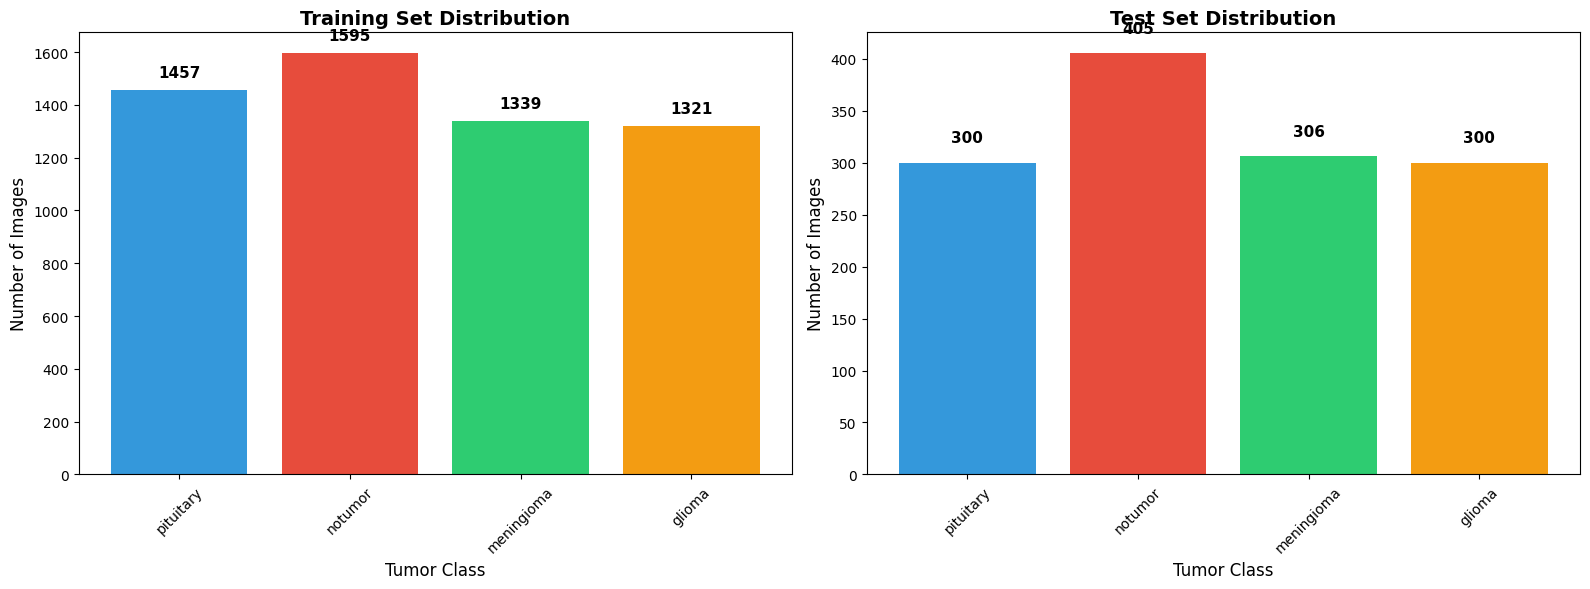

Dataset distribution visualization saved


In [3]:
# Create visualization of dataset distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set distribution
classes = list(train_counts.keys())
train_values = list(train_counts.values())
axes[0].bar(classes, train_values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[0].set_xlabel('Tumor Class', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Training Set Distribution', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for i, count in enumerate(train_values):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=11, fontweight='bold')

# Test set distribution
test_values = list(test_counts.values())
axes[1].bar(classes, test_values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
axes[1].set_xlabel('Tumor Class', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for i, count in enumerate(test_values):
    axes[1].text(i, count + 20, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('Dataset distribution visualization saved')

In [4]:
def load_images_with_labels(base_dir):
    """
    Load all image paths and their labels from directory
    """
    images = []
    labels = []
    
    tumor_classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
    
    for class_name in tumor_classes:
        class_path = os.path.join(base_dir, class_name)
        
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            for img_file in image_files:
                img_path = os.path.join(class_path, img_file)
                images.append(img_path)
                labels.append(class_name)
    
    return images, labels

print('LOADING IMAGE PATHS')

# Load training data paths
print('\nLoading training data paths...')
train_val_paths, train_val_labels = load_images_with_labels(TRAIN_DIR)
print(f'  Total training images: {len(train_val_paths)}')

# Load test data paths
print('Loading test data paths...')
test_paths, test_labels = load_images_with_labels(TEST_DIR)
print(f'  Total test images: {len(test_paths)}')

LOADING IMAGE PATHS

Loading training data paths...
  Total training images: 5712
Loading test data paths...
  Total test images: 1311


In [11]:
# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)

In [13]:
print('SPLITTING DATASET')

# Split training into train/val (80/20) BEFORE any augmentation
print('\nSplitting training set into train/val (80/20)...')

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths,
    train_val_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=train_val_labels
)

print(f'\nDataset split completed:')
print(f'  Train: {len(train_paths)} images (will be augmented 5x)')
print(f'  Val: {len(val_paths)} images (original, no augmentation)')
print(f'  Test: {len(test_paths)} images (original, no augmentation)')

# Verify class distribution in each split
print('CLASS DISTRIBUTION PER SPLIT')

tumor_classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

print('\nTrain set distribution:')
for class_name in tumor_classes:
    count = train_labels.count(class_name)
    print(f'  {class_name}: {count} images')

print('\nValidation set distribution:')
for class_name in tumor_classes:
    count = val_labels.count(class_name)
    print(f'  {class_name}: {count} images')

print('\nTest set distribution:')
for class_name in tumor_classes:
    count = test_labels.count(class_name)
    print(f'  {class_name}: {count} images')

SPLITTING DATASET

Splitting training set into train/val (80/20)...

Dataset split completed:
  Train: 4569 images (will be augmented 5x)
  Val: 1143 images (original, no augmentation)
  Test: 1311 images (original, no augmentation)
CLASS DISTRIBUTION PER SPLIT

Train set distribution:
  glioma: 1057 images
  meningioma: 1071 images
  notumor: 1276 images
  pituitary: 1165 images

Validation set distribution:
  glioma: 264 images
  meningioma: 268 images
  notumor: 319 images
  pituitary: 292 images

Test set distribution:
  glioma: 300 images
  meningioma: 306 images
  notumor: 405 images
  pituitary: 300 images


In [14]:
def load_and_resize_images_batched(image_paths, target_size=256, batch_size=500):
    """
    Load and resize images in batches to avoid memory overflow
    """
    all_images = []
    total_images = len(image_paths)
    num_batches = (total_images + batch_size - 1) // batch_size
    
    print(f'Loading {total_images} images in {num_batches} batches of {batch_size}')
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, total_images)
        
        print(f'Loading batch {batch_idx + 1}/{num_batches}: images {start_idx}-{end_idx}...')
        
        batch_images = []
        for img_path in image_paths[start_idx:end_idx]:
            img = cv2.imread(img_path)
            if img is not None:
                img_resized = cv2.resize(img, (target_size, target_size))
                batch_images.append(img_resized)
        
        all_images.extend(batch_images)
        
        # Clear batch memory
        del batch_images
        gc.collect()
    
    return np.array(all_images)

# Load and resize ONLY training set to 256x256
print('Loading and resizing train set to 256x256...')
train_images_256 = load_and_resize_images_batched(train_paths, target_size=256, batch_size=500)
print(f'Train images loaded: {train_images_256.shape}')

# Store labels as numpy array
train_labels_array = np.array(train_labels)
print('Train labels prepared')

Loading and resizing train set to 256x256...
Loading 4569 images in 10 batches of 500
Loading batch 1/10: images 0-500...
Loading batch 2/10: images 500-1000...
Loading batch 3/10: images 1000-1500...
Loading batch 4/10: images 1500-2000...
Loading batch 5/10: images 2000-2500...
Loading batch 6/10: images 2500-3000...
Loading batch 7/10: images 3000-3500...
Loading batch 8/10: images 3500-4000...
Loading batch 9/10: images 4000-4500...
Loading batch 10/10: images 4500-4569...
Train images loaded: (4569, 256, 256, 3)
Train labels prepared


In [15]:
# Define augmentation
augmentation_generator = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0
)

def augment_images_batched(images, labels, augmentation_factor=4, batch_size=200):
    """
    Augment images in batches to avoid memory overflow
    """
    augmented_images = []
    augmented_labels = []
    
    total_images = len(images)
    num_batches = (total_images + batch_size - 1) // batch_size
    
    print(f'Augmenting {total_images} images in {num_batches} batches of {batch_size}')
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, total_images)
        
        print(f'Augmenting batch {batch_idx + 1}/{num_batches}: images {start_idx}-{end_idx}...')
        
        # Process current batch
        for idx in range(start_idx, end_idx):
            img = images[idx]
            label = labels[idx]
            
            # Reshape for ImageDataGenerator
            img_reshaped = img.reshape(1, img.shape[0], img.shape[1], img.shape[2])
            
            # Generate augmented versions
            aug_count = 0
            for batch in augmentation_generator.flow(img_reshaped, batch_size=1):
                augmented_images.append(batch[0].astype(np.uint8))
                augmented_labels.append(label)
                aug_count += 1
                if aug_count >= augmentation_factor:
                    break
        
        print(f'Batch {batch_idx + 1} complete: {(end_idx - start_idx) * augmentation_factor} augmented images generated')
    
    print('\nConverting augmented data to arrays...')
    return np.array(augmented_images), np.array(augmented_labels)

# Augment training set (5× augmentation)
print('\nAugmenting training set (5× augmentation)...')
print('This will take several minutes...')
train_images_augmented, train_labels_augmented = augment_images_batched(
    train_images_256, 
    train_labels_array, 
    augmentation_factor=5,
    batch_size=200
)

print(f'\nAugmentation complete!')
print(f'Original train images: {len(train_images_256)}')
print(f'Augmented train images: {len(train_images_augmented)}')

# Clear memory
del train_images_256
gc.collect()


Augmenting training set (5× augmentation)...
This will take several minutes...
Augmenting 4569 images in 23 batches of 200
Augmenting batch 1/23: images 0-200...
Batch 1 complete: 1000 augmented images generated
Augmenting batch 2/23: images 200-400...
Batch 2 complete: 1000 augmented images generated
Augmenting batch 3/23: images 400-600...
Batch 3 complete: 1000 augmented images generated
Augmenting batch 4/23: images 600-800...
Batch 4 complete: 1000 augmented images generated
Augmenting batch 5/23: images 800-1000...
Batch 5 complete: 1000 augmented images generated
Augmenting batch 6/23: images 1000-1200...
Batch 6 complete: 1000 augmented images generated
Augmenting batch 7/23: images 1200-1400...
Batch 7 complete: 1000 augmented images generated
Augmenting batch 8/23: images 1400-1600...
Batch 8 complete: 1000 augmented images generated
Augmenting batch 9/23: images 1600-1800...
Batch 9 complete: 1000 augmented images generated
Augmenting batch 10/23: images 1800-2000...
Batch 

0

In [16]:
# Images already at 256x256 from augmentation - just rename for consistency
print('\nImages already at 256x256 - no resizing needed!')
train_images_final_size = train_images_augmented
print(f'Train images: {train_images_final_size.shape}')

# Load and resize validation set to 256x256 (NO AUGMENTATION)
print('\nLoading and resizing validation set to 256x256...')
val_images_256 = load_and_resize_images_batched(val_paths, target_size=256, batch_size=500)
val_labels_array = np.array(val_labels)
print(f'Val images loaded and resized: {val_images_256.shape}')

# Load and resize test set to 256x256 (NO AUGMENTATION)
print('\nLoading and resizing test set to 256x256...')
test_images_256 = load_and_resize_images_batched(test_paths, target_size=256, batch_size=500)
test_labels_array = np.array(test_labels)
print(f'Test images loaded and resized: {test_images_256.shape}')

print('\nAll sets at 256x256:')
print(f'Train: {train_images_final_size.shape} (augmented)')
print(f'Val: {val_images_256.shape} (original)')
print(f'Test: {test_images_256.shape} (original)')


Images already at 256x256 - no resizing needed!
Train images: (22845, 256, 256, 3)

Loading and resizing validation set to 256x256...
Loading 1143 images in 3 batches of 500
Loading batch 1/3: images 0-500...
Loading batch 2/3: images 500-1000...
Loading batch 3/3: images 1000-1143...
Val images loaded and resized: (1143, 256, 256, 3)

Loading and resizing test set to 256x256...
Loading 1311 images in 3 batches of 500
Loading batch 1/3: images 0-500...
Loading batch 2/3: images 500-1000...
Loading batch 3/3: images 1000-1311...
Test images loaded and resized: (1311, 256, 256, 3)

All sets at 256x256:
Train: (22845, 256, 256, 3) (augmented)
Val: (1143, 256, 256, 3) (original)
Test: (1311, 256, 256, 3) (original)


In [17]:
def apply_gamma_correction(images, gamma_value=1.5):
    """
    Apply gamma correction to all images
    """
    corrected_images = images.copy()
    
    for idx in range(len(corrected_images)):
        if idx % 1000 == 0:
            print(f'Gamma correction {idx}/{len(corrected_images)}...')
        
        # Normalize to 0-1
        normalized = corrected_images[idx] / 255.0
        
        # Apply gamma correction
        gamma_corrected = np.power(normalized, gamma_value)
        
        # Denormalize to 0-255
        corrected_images[idx] = (gamma_corrected * 255).astype(np.uint8)
    
    return corrected_images

gamma = 1.5
print(f'\nApplying gamma correction (gamma={gamma}) to all sets...')

# Apply to train set
print('Processing train set...')
train_images_final = apply_gamma_correction(train_images_final_size, gamma)
print(f'Train set: Gamma correction complete')

# Clear memory
del train_images_final_size
gc.collect()

# Apply to val set
print('\nProcessing validation set...')
val_images_final = apply_gamma_correction(val_images_256, gamma)
print(f'Val set: Gamma correction complete')

# Clear memory
del val_images_256
gc.collect()

# Apply to test set
print('\nProcessing test set...')
test_images_final = apply_gamma_correction(test_images_256, gamma)
print(f'Test set: Gamma correction complete')

# Clear memory
del test_images_256
gc.collect()

print('\nGamma correction applied to all sets!')


Applying gamma correction (gamma=1.5) to all sets...
Processing train set...
Gamma correction 0/22845...
Gamma correction 1000/22845...
Gamma correction 2000/22845...
Gamma correction 3000/22845...
Gamma correction 4000/22845...
Gamma correction 5000/22845...
Gamma correction 6000/22845...
Gamma correction 7000/22845...
Gamma correction 8000/22845...
Gamma correction 9000/22845...
Gamma correction 10000/22845...
Gamma correction 11000/22845...
Gamma correction 12000/22845...
Gamma correction 13000/22845...
Gamma correction 14000/22845...
Gamma correction 15000/22845...
Gamma correction 16000/22845...
Gamma correction 17000/22845...
Gamma correction 18000/22845...
Gamma correction 19000/22845...
Gamma correction 20000/22845...
Gamma correction 21000/22845...
Gamma correction 22000/22845...
Train set: Gamma correction complete

Processing validation set...
Gamma correction 0/1143...
Gamma correction 1000/1143...
Val set: Gamma correction complete

Processing test set...
Gamma correction

Generating preprocessing comparison visualization...


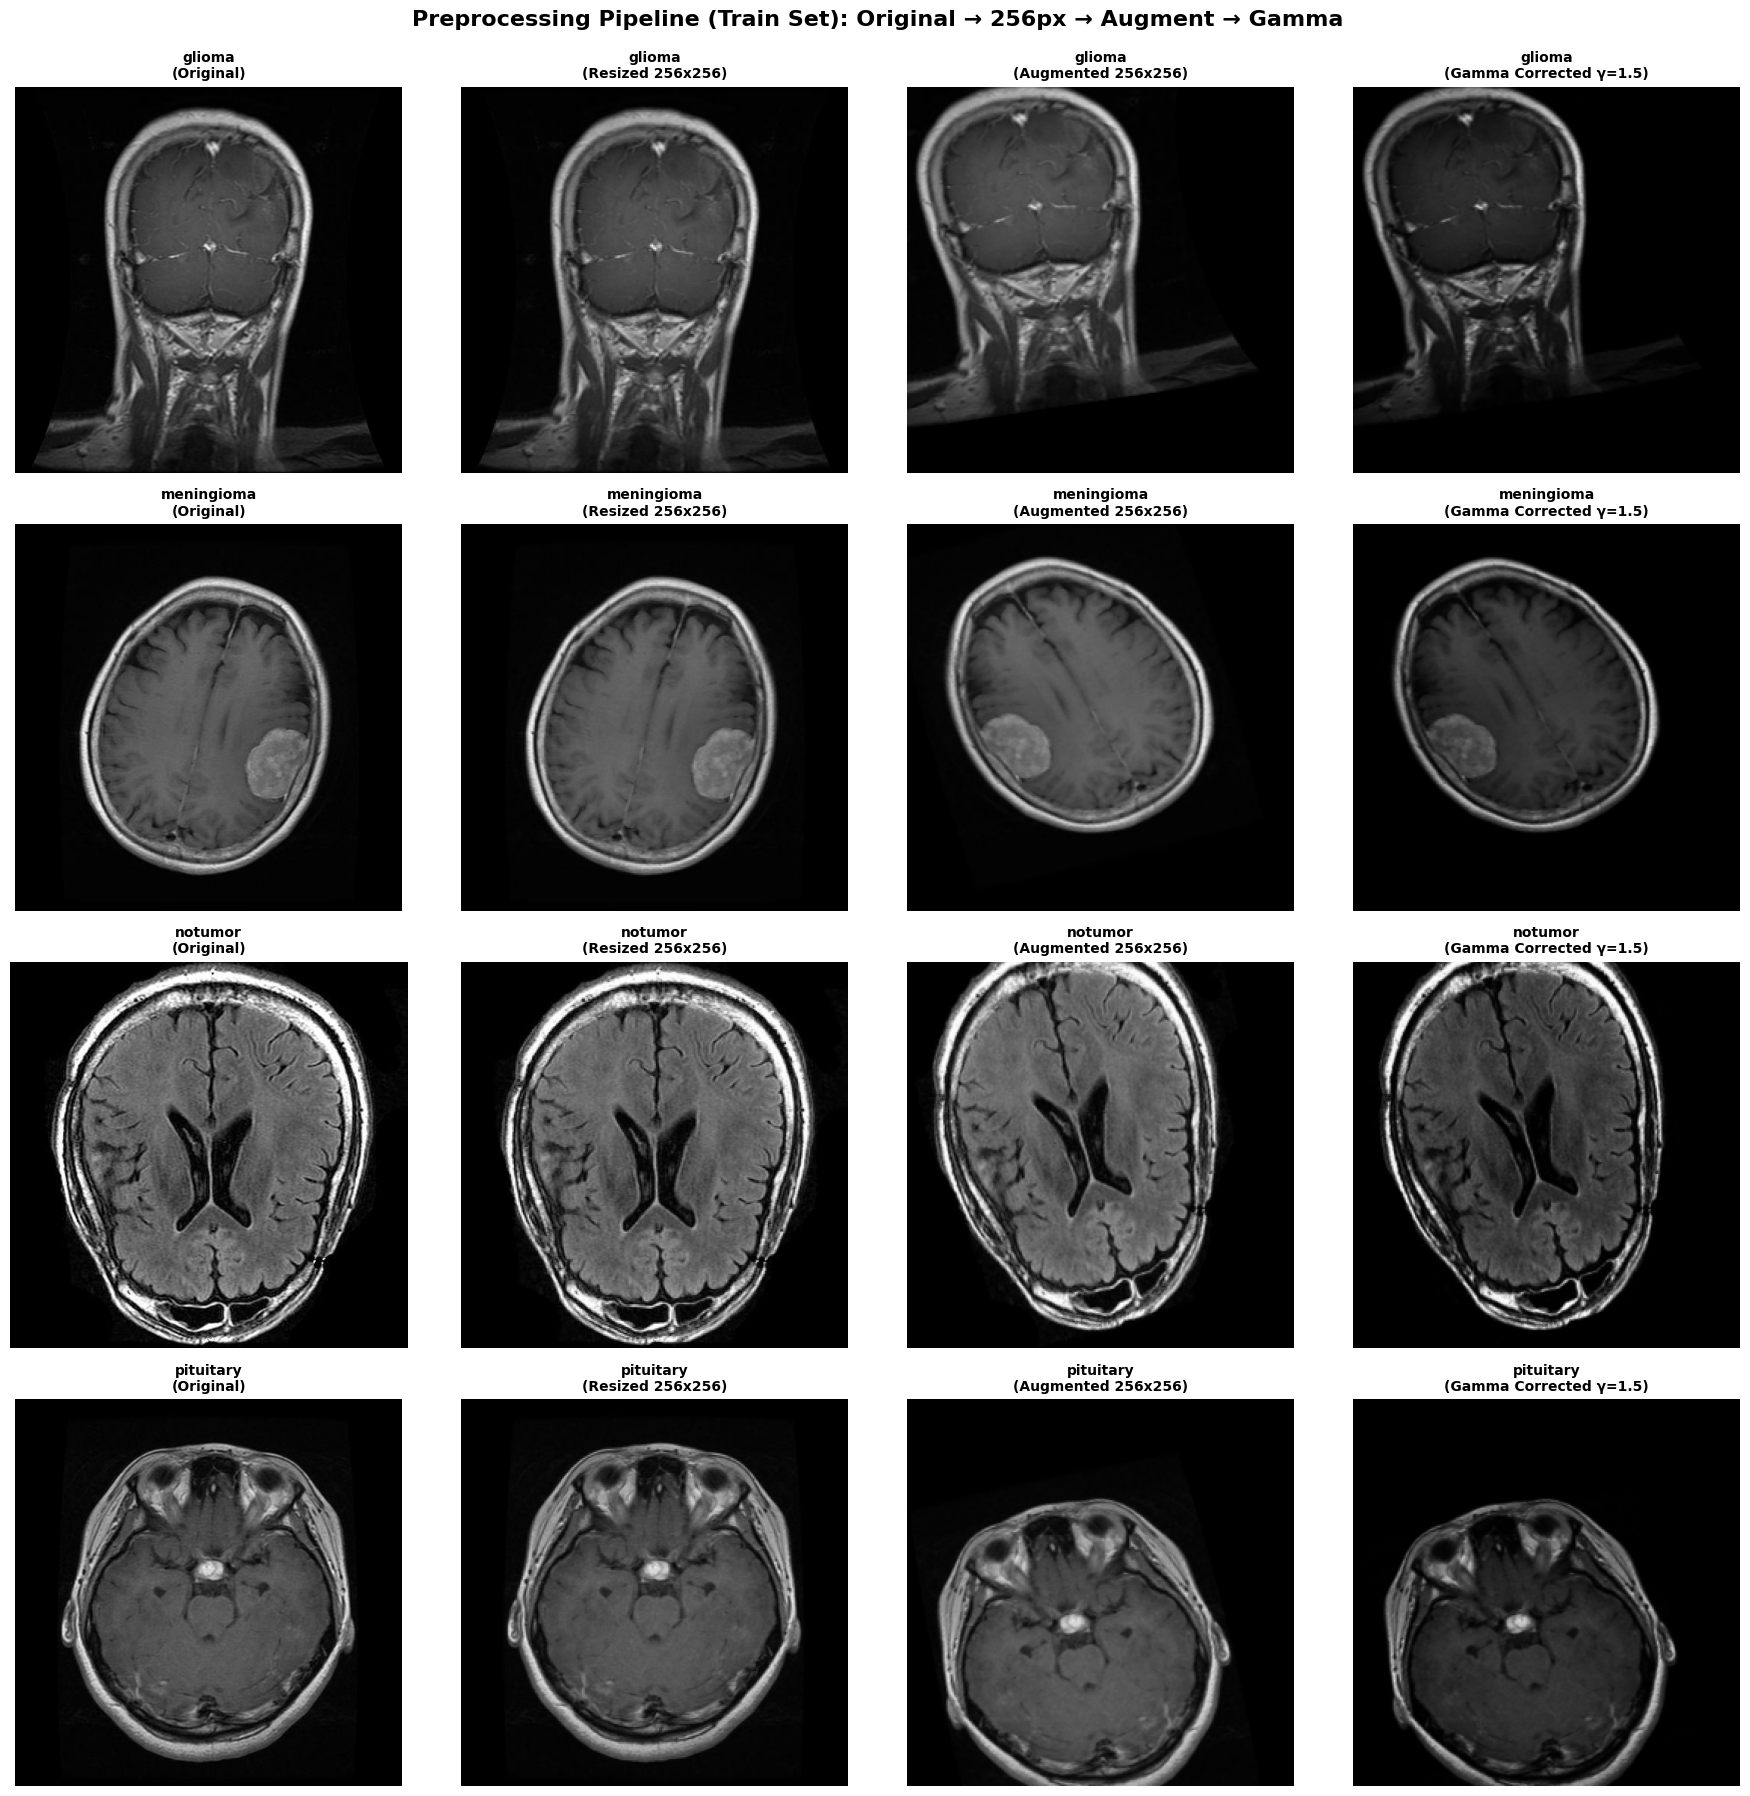

Preprocessing comparison saved


In [18]:
def show_preprocessing_comparison_train():
    """
    Display preprocessing stages using images from TRAIN set only
    Pipeline: Original → 256px → Augment → Gamma
    """
    fig, axes = plt.subplots(4, 4, figsize=(18, 18))
    
    tumor_classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
    
    for i, class_name in enumerate(tumor_classes):
        # Get one train image path for this class
        class_train_paths = [p for p, l in zip(train_paths, train_labels) if l == class_name]
        img_path = class_train_paths[0]
        
        # Stage 1: Original image
        original_img = cv2.imread(img_path)
        original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        
        # Stage 2: Resized to 256x256
        resized_256 = cv2.resize(original_img_rgb, (256, 256))
        
        # Stage 3: Simulate augmentation at 256x256
        img_for_aug = resized_256.reshape(1, 256, 256, 3)
        aug_gen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            zoom_range=0.15,
            shear_range=0.15,
            horizontal_flip=True,
            fill_mode='constant',
            cval=0
        )
        aug_iter = aug_gen.flow(img_for_aug, batch_size=1)
        augmented_img = next(aug_iter)[0].astype(np.uint8)
        
        # Stage 4: Gamma corrected
        normalized = augmented_img / 255.0
        gamma_corrected = np.power(normalized, 1.5)
        gamma_corrected = (gamma_corrected * 255).astype(np.uint8)
        
        # Plot all stages
        axes[i, 0].imshow(original_img_rgb)
        axes[i, 0].set_title(f'{class_name}\n(Original)', fontsize=10, fontweight='bold')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(resized_256)
        axes[i, 1].set_title(f'{class_name}\n(Resized 256x256)', fontsize=10, fontweight='bold')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(augmented_img)
        axes[i, 2].set_title(f'{class_name}\n(Augmented 256x256)', fontsize=10, fontweight='bold')
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(gamma_corrected)
        axes[i, 3].set_title(f'{class_name}\n(Gamma Corrected γ=1.5)', fontsize=10, fontweight='bold')
        axes[i, 3].axis('off')
    
    plt.suptitle('Preprocessing Pipeline (Train Set): Original → 256px → Augment → Gamma', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('preprocessing_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Generating preprocessing comparison visualization...')
show_preprocessing_comparison_train()
print('Preprocessing comparison saved')

In [19]:
# Save train set
print('\nSaving preprocessed train set...')
np.save('/kaggle/working/preprocessed_train_images.npy', train_images_final)
np.save('/kaggle/working/preprocessed_train_labels.npy', train_labels_augmented)
print(f'Train set saved: {train_images_final.shape}')

# Save validation set
print('Saving preprocessed validation set...')
np.save('/kaggle/working/preprocessed_val_images.npy', val_images_final)
np.save('/kaggle/working/preprocessed_val_labels.npy', val_labels_array)
print(f'Val set saved: {val_images_final.shape}')

# Save test set
print('Saving preprocessed test set...')
np.save('/kaggle/working/preprocessed_test_images.npy', test_images_final)
np.save('/kaggle/working/preprocessed_test_labels.npy', test_labels_array)
print(f'Test set saved: {test_images_final.shape}')

# Save label encoder classes for reference
tumor_categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
np.save('/kaggle/working/label_classes.npy', np.array(tumor_categories))

print('\nAll .npy files saved successfully!')
print('\nFiles created:')
print('1. preprocessed_train_images.npy')
print('2. preprocessed_train_labels.npy')
print('3. preprocessed_val_images.npy')
print('4. preprocessed_val_labels.npy')
print('5. preprocessed_test_images.npy')
print('6. preprocessed_test_labels.npy')
print('7. label_classes.npy')


Saving preprocessed train set...
Train set saved: (22845, 256, 256, 3)
Saving preprocessed validation set...
Val set saved: (1143, 256, 256, 3)
Saving preprocessed test set...
Test set saved: (1311, 256, 256, 3)

All .npy files saved successfully!

Files created:
1. preprocessed_train_images.npy
2. preprocessed_train_labels.npy
3. preprocessed_val_images.npy
4. preprocessed_val_labels.npy
5. preprocessed_test_images.npy
6. preprocessed_test_labels.npy
7. label_classes.npy


In [20]:
# Create folder structure: train/val/test → each has 4 class folders
FINAL_DIR = '/kaggle/working/final_preprocessed_dataset'

print('\nCreating folder structure for zip file...')

# Create directories
for split in ['train', 'validation', 'test']:
    for class_name in ['glioma', 'meningioma', 'notumor', 'pituitary']:
        folder_path = os.path.join(FINAL_DIR, split, class_name)
        os.makedirs(folder_path, exist_ok=True)

print('Folder structure created')

# Save train images
print('\nSaving train images to folders...')
for idx, (img, label) in enumerate(zip(train_images_final, train_labels_augmented)):
    if idx % 1000 == 0:
        print(f'Saving train image {idx}/{len(train_images_final)}...')
    
    class_folder = os.path.join(FINAL_DIR, 'train', label)
    img_filename = f'{label}_{idx:05d}.jpg'
    img_path = os.path.join(class_folder, img_filename)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    img_pil.save(img_path, quality=95)

print(f'Train images saved: {len(train_images_final)} images')

# Save validation images
print('\nSaving validation images to folders...')
for idx, (img, label) in enumerate(zip(val_images_final, val_labels_array)):
    if idx % 200 == 0:
        print(f'Saving val image {idx}/{len(val_images_final)}...')
    
    class_folder = os.path.join(FINAL_DIR, 'validation', label)
    img_filename = f'{label}_{idx:05d}.jpg'
    img_path = os.path.join(class_folder, img_filename)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    img_pil.save(img_path, quality=95)

print(f'Validation images saved: {len(val_images_final)} images')

# Save test images
print('\nSaving test images to folders...')
for idx, (img, label) in enumerate(zip(test_images_final, test_labels_array)):
    if idx % 100 == 0:
        print(f'Saving test image {idx}/{len(test_images_final)}...')
    
    class_folder = os.path.join(FINAL_DIR, 'test', label)
    img_filename = f'{label}_{idx:05d}.jpg'
    img_path = os.path.join(class_folder, img_filename)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    img_pil.save(img_path, quality=95)

print(f'Test images saved: {len(test_images_final)} images')


Creating folder structure for zip file...
Folder structure created

Saving train images to folders...
Saving train image 0/22845...
Saving train image 1000/22845...
Saving train image 2000/22845...
Saving train image 3000/22845...
Saving train image 4000/22845...
Saving train image 5000/22845...
Saving train image 6000/22845...
Saving train image 7000/22845...
Saving train image 8000/22845...
Saving train image 9000/22845...
Saving train image 10000/22845...
Saving train image 11000/22845...
Saving train image 12000/22845...
Saving train image 13000/22845...
Saving train image 14000/22845...
Saving train image 15000/22845...
Saving train image 16000/22845...
Saving train image 17000/22845...
Saving train image 18000/22845...
Saving train image 19000/22845...
Saving train image 20000/22845...
Saving train image 21000/22845...
Saving train image 22000/22845...
Train images saved: 22845 images

Saving validation images to folders...
Saving val image 0/1143...
Saving val image 200/1143...

In [21]:
# Verify saved images
print('VERIFICATION: Images saved in folders')

for split in ['train', 'validation', 'test']:
    print(f'\n{split.upper()} SET:')
    for class_name in ['glioma', 'meningioma', 'notumor', 'pituitary']:
        folder_path = os.path.join(FINAL_DIR, split, class_name)
        count = len([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        print(f'  {class_name}: {count} images')

# Create zip file
print('Creating zip archive...')

zip_filename = '/kaggle/working/final_preprocessed_dataset'
shutil.make_archive(zip_filename, 'zip', FINAL_DIR)

zip_path = f'{zip_filename}.zip'
zip_size = os.path.getsize(zip_path) / (1024**2)

print(f'\nZip archive created successfully!')
print(f'File: {zip_filename}.zip')
print(f'Size: {zip_size:.2f} MB')

VERIFICATION: Images saved in folders

TRAIN SET:
  glioma: 5285 images
  meningioma: 5355 images
  notumor: 6380 images
  pituitary: 5825 images

VALIDATION SET:
  glioma: 264 images
  meningioma: 268 images
  notumor: 319 images
  pituitary: 292 images

TEST SET:
  glioma: 300 images
  meningioma: 306 images
  notumor: 405 images
  pituitary: 300 images
Creating zip archive...

Zip archive created successfully!
File: /kaggle/working/final_preprocessed_dataset.zip
Size: 357.89 MB
